# TP4 AA1

**Escriba aquí su nombre completo**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 - 10 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo


air_quality = fetch_ucirepo(id=360)

X = air_quality.data.features # Las variables (sensores, temperatura, humedad)

print(X.head())

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  3/10/2004  18:00:00     2.6         1360       150      11.9   
1  3/10/2004  19:00:00     2.0         1292       112       9.4   
2  3/10/2004  20:00:00     2.2         1402        88       9.0   
3  3/10/2004  21:00:00     2.2         1376        80       9.2   
4  3/10/2004  22:00:00     1.6         1272        51       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0           1046      166          1056      113          1692         1268   
1            955      103          1174       92          1559          972   
2            939      131          1140      114          1555         1074   
3            948      172          1092      122          1584         1203   
4            836      131          1205      116          1490         1110   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  0.7502  
3  11.0  60.0  0.7867  
4 

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame(X)
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


| Variable          | Descripción                                                                                                                                                                                       |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Date**          | Fecha de la medición.                                                                                                                                                                             |
| **Time**          | Hora de la medición.                                                                                                                                                                              |
| **CO(GT)**        | Concentración real de **Monóxido de Carbono (CO, Carbon Monoxide)** medida por un equipo de referencia. **GT (Ground Truth)** indica que es una medición certificada considerada como valor real. |
| **PT08.S1(CO)**   | Lectura del sensor químico **PT08 Sensor 1**, diseñado para detectar variaciones asociadas al **Monóxido de Carbono (CO)**.                                                                       |
| **NMHC(GT)**      | Concentración real de **Hidrocarburos No Metánicos (NMHC, Non-Methane HydroCarbons)** medida por un equipo de referencia.                                                                         |
| **C6H6(GT)**      | Concentración real de **Benceno (C₆H₆)**, un compuesto orgánico volátil presente en combustibles y emisiones vehiculares.                                                                         |
| **PT08.S2(NMHC)** | Lectura del sensor químico **PT08 Sensor 2**, asociado a la detección de **Hidrocarburos No Metánicos (NMHC)**.                                                                                   |
| **NOx(GT)**       | Concentración real de **Óxidos de Nitrógeno (NOx, Nitrogen Oxides)**, grupo de gases contaminantes formados principalmente por NO y NO₂.                                                          |
| **PT08.S3(NOx)**  | Lectura del sensor químico **PT08 Sensor 3**, asociado a la detección de **Óxidos de Nitrógeno (NOx)**.                                                                                           |
| **NO2(GT)**       | Concentración real de **Dióxido de Nitrógeno (NO₂, Nitrogen Dioxide)** medida por un equipo de referencia.                                                                                        |
| **PT08.S4(NO2)**  | Lectura del sensor químico **PT08 Sensor 4**, asociado a la detección de **Dióxido de Nitrógeno (NO₂)**.                                                                                          |
| **PT08.S5(O3)**   | Lectura del sensor químico **PT08 Sensor 5**, relacionado con la detección de **Ozono (O₃, Ozone)**.                                                                                              |
| **T**             | **Temperatura (Temperature)** del aire expresada en grados Celsius (°C).                                                                                                                          |
| **RH**            | **Humedad Relativa (Relative Humidity)** expresada como porcentaje (%). Indica qué tan cerca está el aire de alcanzar la saturación de vapor de agua.                                             |
| **AH**            | **Humedad Absoluta (Absolute Humidity)**. Representa la cantidad real de vapor de agua presente en el aire.                                                                                       |


## DataSet utilizado  :  Air Quality (UCI)
Es un dataSet publicado originalmente publicado en 2008 posteriormente incorporado en los repositorios de la UCI (universidad de California en Irvine).

- este dataset contiene datos de mediciones de sensores que fueron instalados en una ciudad italiana en zona urbana con alta contaminación y a nivel de calle.

Los datos de este conjunto de datos fueron recolectados con dos tipos de sensores :

- Equipos profesionales certificados → miden la concentración real del contaminante.
Sensores químicos de bajo costo (PT08) → intentan estimar esa concentración.

- Sensores químicos de bajo costo (PT08) → intentan estimar esa concentración.

## Variables medidas con sensores de bajo costo

| Variable      | Sensor asociado                 |
| ------------- | ------------------------------- |
| PT08.S1(CO)   | Sensor sensible al CO           |
| PT08.S2(NMHC) | Sensor sensible a hidrocarburos |
| PT08.S3(NOx)  | Sensor sensible a NOx           |
| PT08.S4(NO2)  | Sensor sensible a NO₂           |
| PT08.S5(O3)   | Sensor relacionado con O₃       |

Características:

✅ Mucho más baratos.

✅ Fáciles de instalar.

✅ Consumen poca energía.

❌ Menos precisos.

❌ Se ven afectados por temperatura y humedad.

❌ Su precisión puede degradarse con el tiempo (sensor drift).

## Variables medidas con equipos certificados (Ground Truth)

| Variable | Qué mide                                         |
| -------- | ------------------------------------------------ |
| CO(GT)   | Concentración real de monóxido de carbono        |
| NMHC(GT) | Concentración real de hidrocarburos no metánicos |
| C6H6(GT) | Concentración real de benceno                    |
| NOx(GT)  | Concentración real de óxidos de nitrógeno        |
| NO2(GT)  | Concentración real de dióxido de nitrógeno       |


Características:

✅ Muy precisos.

✅ Están calibrados bajo normas internacionales.

✅ Pueden medir directamente la concentración real del contaminante.

❌ Son caros.

❌ Requieren mantenimiento especializado.

❌ Consumen más energía.

❌ Suelen requerir personal especializado.

❌ Es difícil instalar una gran cantidad de ellos en una ciudad.

El objetivo de este análisis es evaluar si las mediciones obtenidas por sensores de bajo costo, junto con variables meteorológicas como la temperatura y la humedad, permiten estimar con precisión las mediciones realizadas por equipos certificados de referencia.

La variable objetivo seleccionada es CO(GT), que representa la concentración de Monóxido de Carbono (CO) medida por un equipo certificado de alta precisión (Ground Truth).

La elección de esta variable se justifica por la importancia del monóxido de carbono como contaminante atmosférico y su impacto sobre la salud humana. Según el Ministerio de Salud de Argentina, la exposición a altas concentraciones de monóxido de carbono reduce la capacidad de la sangre para transportar oxígeno, impidiendo que las células utilicen adecuadamente el oxígeno disponible. Esta disminución del aporte de oxígeno afecta principalmente al cerebro y al corazón, pudiendo provocar síntomas que van desde dolores de cabeza y mareos hasta consecuencias graves en exposiciones prolongadas o a concentraciones elevadas.

Por lo tanto, se buscará desarrollar un modelo predictivo capaz de estimar la concentración de CO(GT) a partir de las lecturas de los sensores PT08 (sensores mas accesibles y menos precisos ) y de las variables meteorológicas disponibles en el dataset.


## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


In [ ]:
df.head(3)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502


In [ ]:
display (df.columns)
df.info()

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [ ]:
# convierto las variables object a formato fecha o hora
df['Date'] = pd.to_datetime(df['Date']).dt.date
df['Time'] = pd.to_datetime(df['Time']).dt.time

/tmp/ipykernel_5249/2341628233.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time']).dt.time


In [ ]:
display(df['Date'].min(),df['Date'].max())

datetime.date(2004, 3, 10)

datetime.date(2005, 4, 4)

- El conjunto de datos no presenta valores nulos en ninguna de sus variables
- se presentan 2 variables de tipo fecha y hora (cada registro representa las mediciones de cada hora de cada dia desde el 10/03/2004 hasta el 04/04/2005 )
- se presentan 5 mediciones de tipo numerico flotante
- Se presentan 8 mediciones de tipo entero

In [ ]:
df = df[['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH']]

df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


- Se puede observar como todas las variables tienen sus mediciones en distintas escalas y manejan distintos grados de variación entre las mismas, pero hay una extraña coincidencia en los minimos de todas las variables (todas las variables tienen un minimo en -200)
- -200 según la documentación representa la no medición o la falta de datos.

In [ ]:
df = df.replace(-200,np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       914 non-null    float64
 3   C6H6(GT)       8991 non-null   float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        7718 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)        7715 non-null   float64
 8   PT08.S4(NO2)   8991 non-null   float64
 9   PT08.S5(O3)    8991 non-null   float64
 10  T              8991 non-null   float64
 11  RH             8991 non-null   float64
 12  AH             8991 non-null   float64
dtypes: float64(13)
memory usage: 950.4 KB


In [ ]:
display(f'NO2(GT) : tiene {df['NO2(GT)'].isna().sum()} nulos ({(df['NO2(GT)'].isna().sum() / df.shape[0]*100).round(2)}%), NOx(GT) : tiene {df['NOx(GT)'].isna().sum()} nulos ({(df['NOx(GT)'].isna().sum() / df.shape[0]*100).round(2)}%),  NMHC(GT) : tiene {df['NMHC(GT)'].isna().sum()} nulos ({(df['NMHC(GT)'].isna().sum() / df.shape[0]*100).round(2)}%), CO(GT) : tiene {df['CO(GT)'].isna().sum()} nulos ({(df['CO(GT)'].isna().sum() / df.shape[0]*100).round(2)}%)')

'NO2(GT) : tiene 1642 nulos (17.55%), NOx(GT) : tiene 1639 nulos (17.52%),  NMHC(GT) : tiene 8443 nulos (90.23%), CO(GT) : tiene 1683 nulos (17.99%)'

NMHC(GT) : es una variable muy poco confiable a la hora de analizar o utilizarla para entrenar un modelo ya que el mas  del 90% de sus datos son nulos

ahora detecto

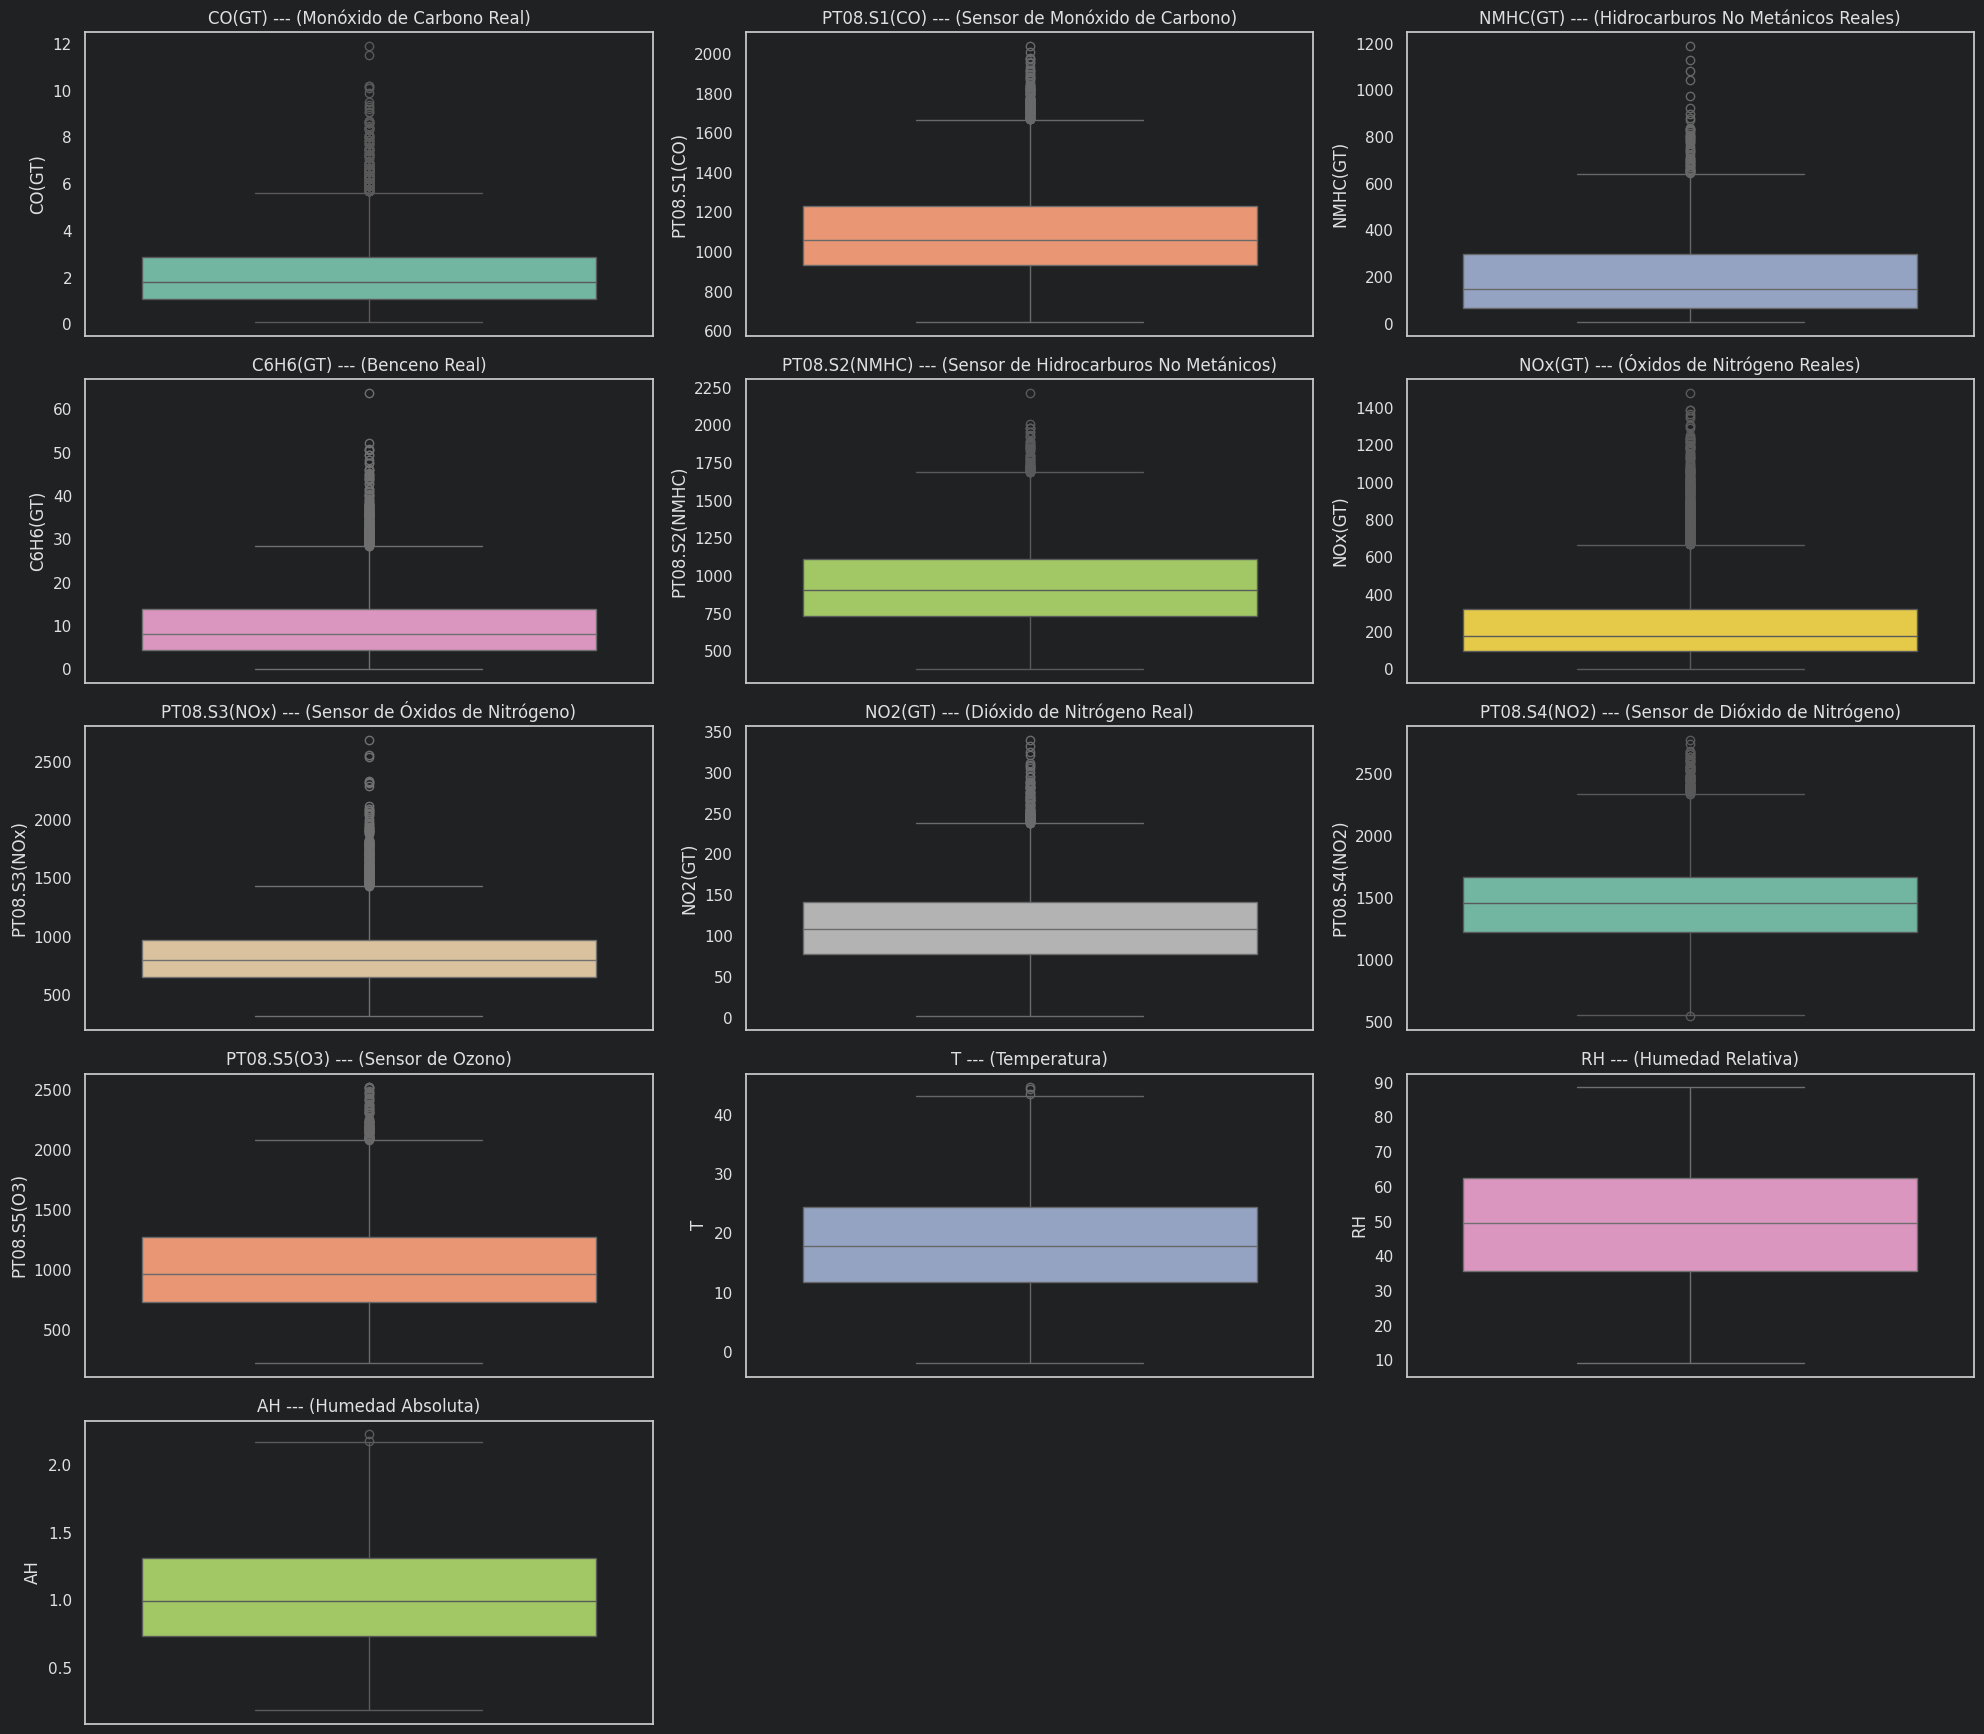

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


dark = {
    "axes.facecolor": "#202123",
    "figure.facecolor": "#202123",
    "axes.edgecolor": "#CCCCCC",
    "axes.labelcolor": "#E0E0E0",
    "xtick.color": "#E0E0E0",
    "ytick.color": "#E0E0E0",
    "grid.color": "#444444",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "text.color": "#E0E0E0",
    "lines.color": "#10A37F",
    "patch.edgecolor": "#E0E0E0",
    "axes.titleweight": "bold",
    "axes.titlesize": 20,
    "axes.labelsize": 18
}

sns.set_theme(style=dark)
colores = sns.color_palette("Set2", n_colors=len(df.columns))

titulos = [
    'CO(GT) --- (Monóxido de Carbono Real)',
    'PT08.S1(CO) --- (Sensor de Monóxido de Carbono)',
    'NMHC(GT) --- (Hidrocarburos No Metánicos Reales)',
    'C6H6(GT) --- (Benceno Real)',
    'PT08.S2(NMHC) --- (Sensor de Hidrocarburos No Metánicos)',
    'NOx(GT) --- (Óxidos de Nitrógeno Reales)',
    'PT08.S3(NOx) --- (Sensor de Óxidos de Nitrógeno)',
    'NO2(GT) --- (Dióxido de Nitrógeno Real)',
    'PT08.S4(NO2) --- (Sensor de Dióxido de Nitrógeno)',
    'PT08.S5(O3) --- (Sensor de Ozono)',
    'T --- (Temperatura)',
    'RH --- (Humedad Relativa)',
    'AH --- (Humedad Absoluta)'
]

# 1. Definir columnas de la cuadrícula y calcular las filas automáticamente
n_cols_grid = 3
n_filas_grid = int(np.ceil(len(df.columns) / n_cols_grid))

# 2. Crear la figura dinámica
figbox, axesbox = plt.subplots(n_filas_grid, n_cols_grid, figsize=(20, n_filas_grid * 3.5))

# 3. Aplanar la matriz de ejes para usar un solo índice simple [i]
axes_flat = axesbox.flatten()

# 4. Graficar cada columna
for i, column in enumerate(df.columns):
    sns.boxplot(data=df, y=column, ax=axes_flat[i],color=colores[i])
    axes_flat[i].set_title(titulos[i])

# 5. Ocultar los ejes que queden vacíos si el total de columnas no es múltiplo de 3
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()


Las mediciones de Monóxido de Carbono (CO), Benceno (C₆H₆), Óxidos de Nitrógeno (NOx), Dióxido de Nitrógeno (NO₂) y las lecturas del sensor de Ozono (O₃) presentan una baja dispersión en el 50% central de los datos, evidenciada por un rango intercuartílico relativamente pequeño. Esto indica que los niveles habituales de estas variables se mantienen relativamente estables. Sin embargo, los boxplots muestran numerosos valores atípicos en el extremo superior, lo que sugiere la ocurrencia de episodios puntuales de contaminación significativamente más elevados que los niveles normales registrados durante el período de estudio.

## Resolución:

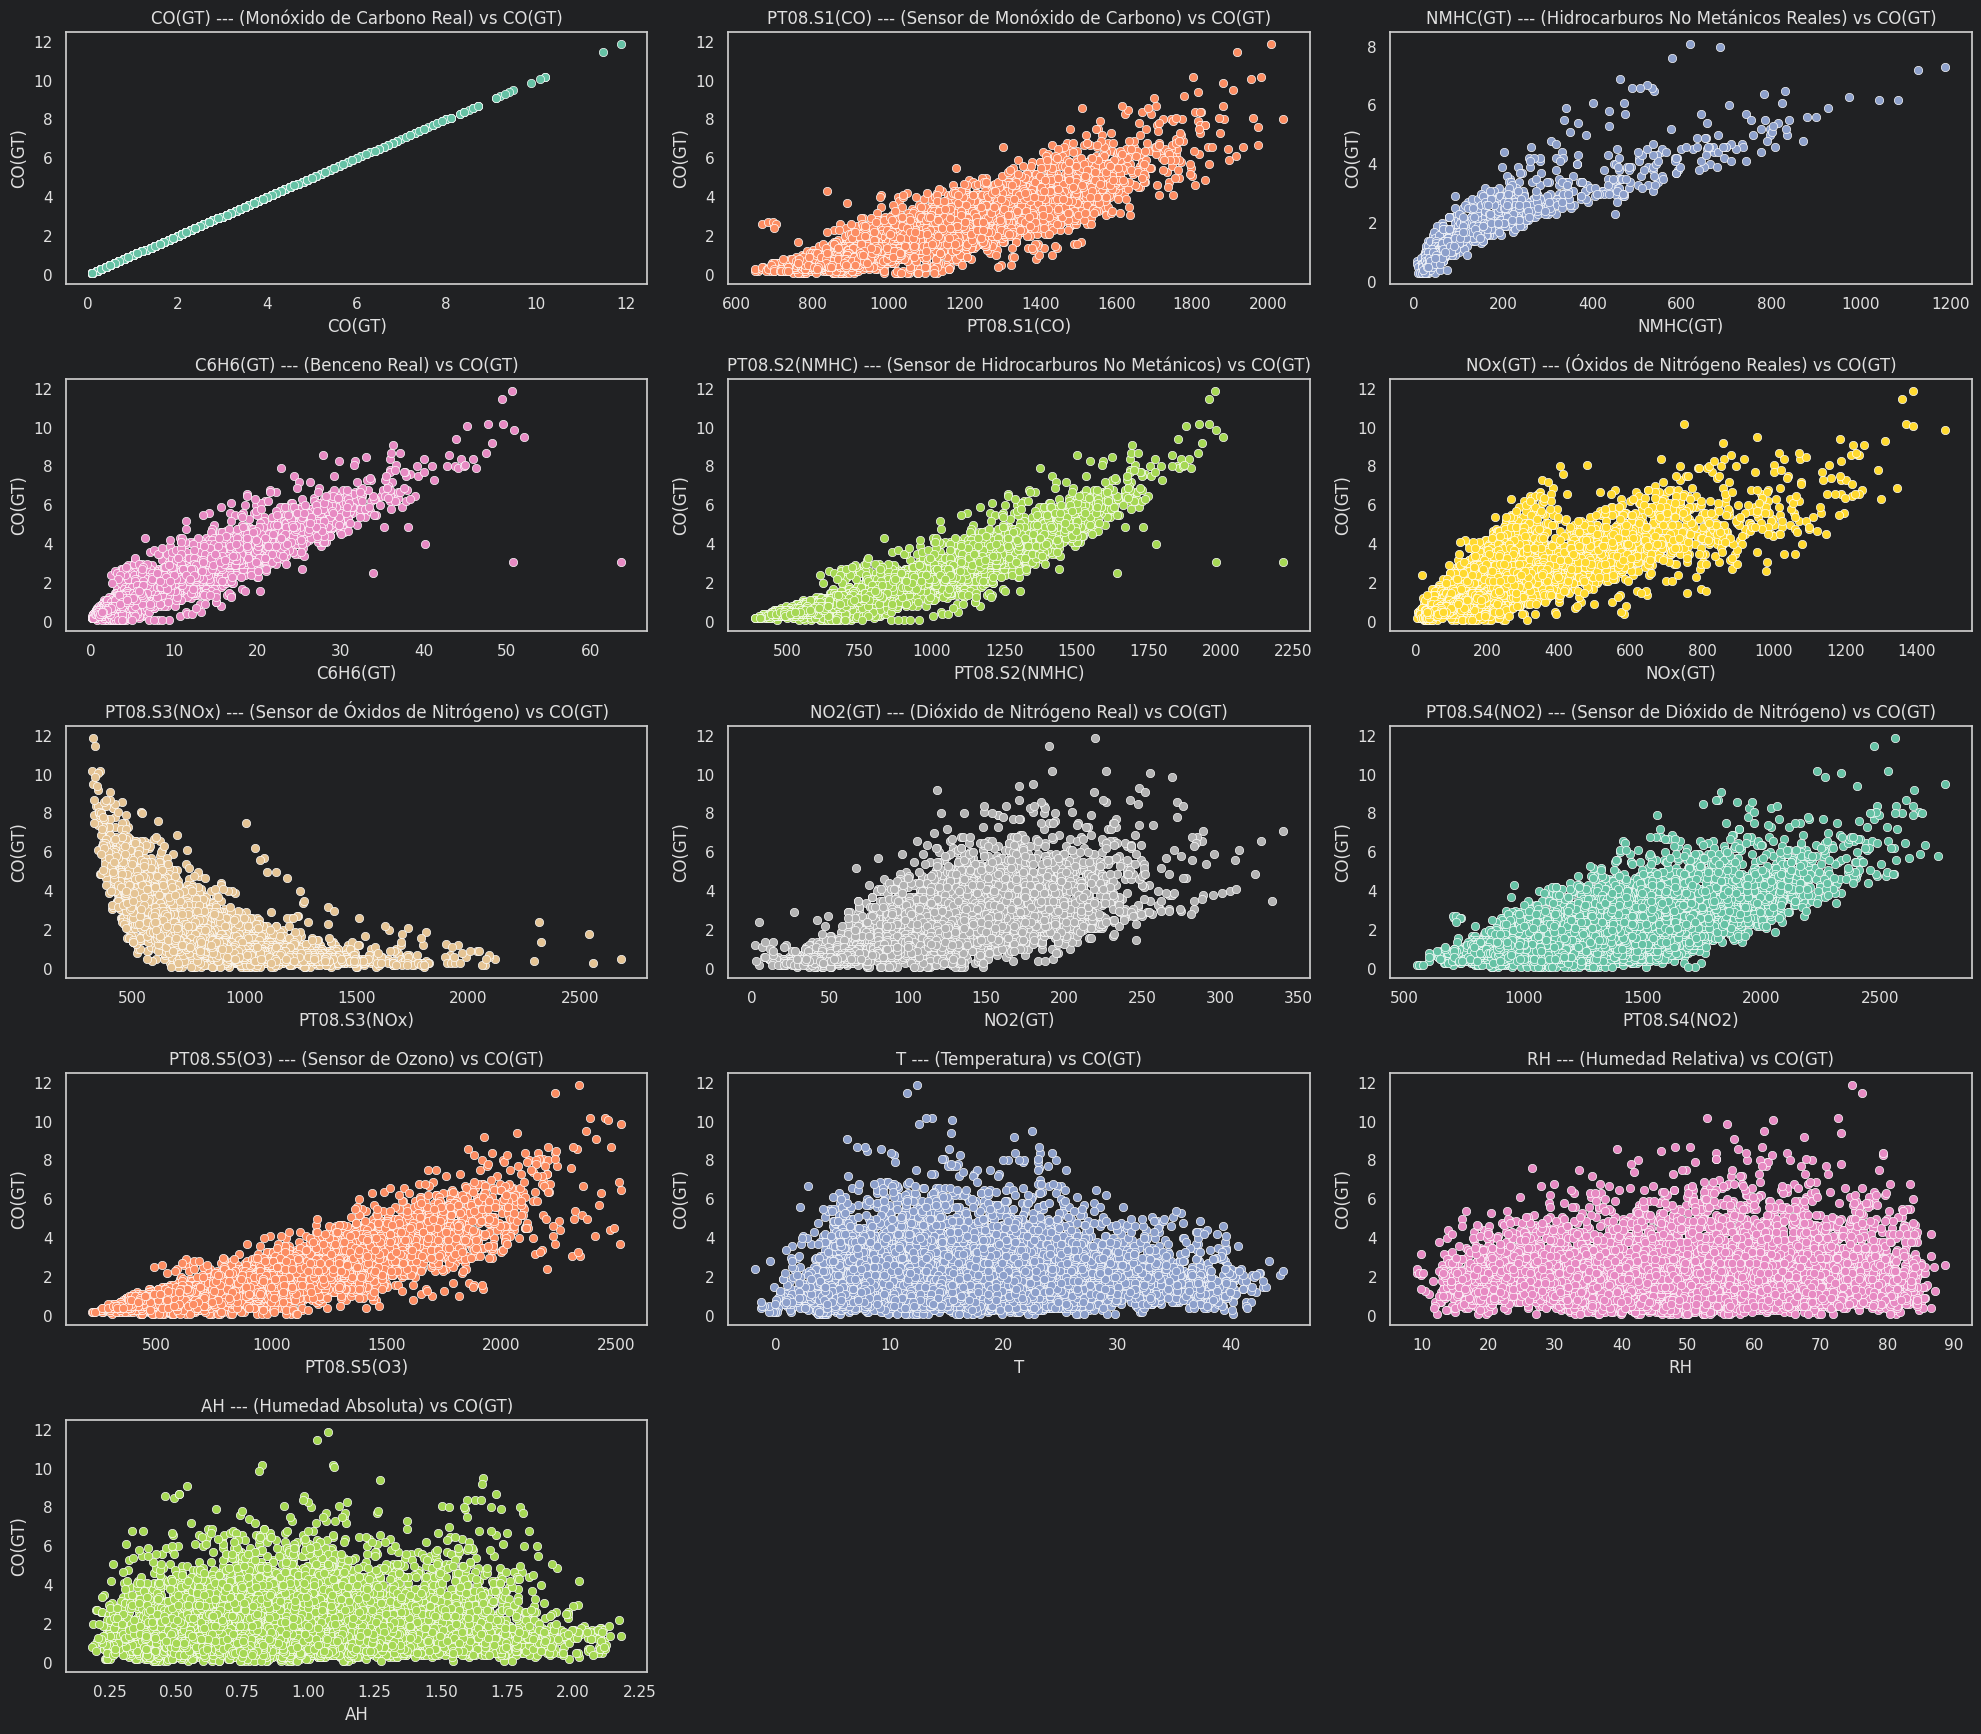

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

colores = sns.color_palette("Set2", n_colors=len(df.columns))




# 1. Definir columnas de la cuadrícula y calcular las filas automáticamente
n_cols_grid = 3
n_filas_grid = int(np.ceil(len(df.columns) / n_cols_grid))

# 2. Crear la figura dinámica
figbox, axesbox = plt.subplots(n_filas_grid, n_cols_grid, figsize=(20, n_filas_grid * 3.5))

# 3. Aplanar la matriz de ejes para usar un solo índice simple [i]
axes_flat = axesbox.flatten()

# 4. Graficar cada columna
for i, column in enumerate(df):
        sns.scatterplot(data=df,x=column,y='CO(GT)', ax=axes_flat[i],color=colores[i])
        axes_flat[i].set_title(f'{titulos[i]} vs CO(GT)')

# 5. Ocultar los ejes que queden vacíos si el total de columnas no es múltiplo de 3
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()


- Visualmente puedo notar que existen relaciones fuertemente positivas entre la variable objetivo (Concentración Real de Monóxido de Carbono) y las variables Lectura del Sensor de Monóxido de Carbono, Lectura del Sensor de Hidrocarburos No Metánicos, Concentración Real de Dióxido de Nitrógeno y Lectura del Sensor de Ozono.

- También detecto una posible logaritmica negativa entre la variable objetivo (Concentración Real de Monóxido de Carbono) y la Lectura del Sensor de Óxidos de Nitrógeno.

- Visualmente, no encuentro una relación significativa entre la variable objetivo (Concentración Real de Monóxido de Carbono) y las mediciones de Temperatura del Aire, Humedad Relativa y Humedad Absoluta.

In [ ]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

list_pearson_spearman = []

for column in df:
    df_temp = df.loc[~df['CO(GT)'].isna(),:]
    if column != 'CO(GT)':
        col_temp = df_temp.loc[~df[column].isna(),:]
        pearson, _ = pearsonr(col_temp[column], col_temp['CO(GT)'])
        spearman, _ = spearmanr(col_temp[column], col_temp['CO(GT)'])
        list_pearson_spearman.append({'columna' : column ,'valor pearson' : pearson,'valor spearman' : spearman})

list_pearson_spearman = pd.DataFrame(list_pearson_spearman)
list_pearson_spearman.sort_values(by='valor pearson',ascending=False)
display(list_pearson_spearman)

,columna,valor pearson,valor spearman
0,PT08.S1(CO),0.879288,0.879422
1,NMHC(GT),0.889734,0.936076
2,C6H6(GT),0.931078,0.926981
3,PT08.S2(NMHC),0.915514,0.926978
4,NOx(GT),0.795028,0.784544
5,PT08.S3(NOx),-0.703446,-0.811156
6,NO2(GT),0.683343,0.734537
7,PT08.S4(NO2),0.630703,0.594367
8,PT08.S5(O3),0.854182,0.855705
9,T,0.022109,0.068907


Para el entrenamiento del modelo se utilizará como variable objetivo únicamente CO(GT), correspondiente a la medición de referencia de alta precisión de la concentración real de monóxido de carbono.

Como variables predictoras se emplearán todas las lecturas provenientes de los sensores de bajo costo (PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2) y PT08.S5(O3)), junto con las variables meteorológicas disponibles en el dataset: temperatura del aire, humedad relativa y humedad absoluta.

Las restantes mediciones de referencia (NMHC(GT), C6H6(GT), NOx(GT) y NO2(GT)) no serán utilizadas como variables predictoras, ya que el objetivo del estudio es evaluar la capacidad de los sensores de bajo costo y de las variables ambientales para estimar la concentración real de monóxido de carbono medida por un equipo certificado.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

,columna,valor pearson,valor spearman
3,PT08.S2(NMHC),0.915514,0.926978
0,PT08.S1(CO),0.879288,0.879422
8,PT08.S5(O3),0.854182,0.855705
7,PT08.S4(NO2),0.630703,0.594367
10,RH,0.048890,-0.006484
11,AH,0.048556,0.053475
9,T,0.022109,0.068907
5,PT08.S3(NOx),-0.703446,-0.811156


/tmp/ipykernel_5249/1322798386.py:20: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(data=df_long,x='columna',y='Correlación',hue='Metodo',order=filter_list_pearson_spearman['columna'].values,palette=sns.color_palette(palette='Dark2'))


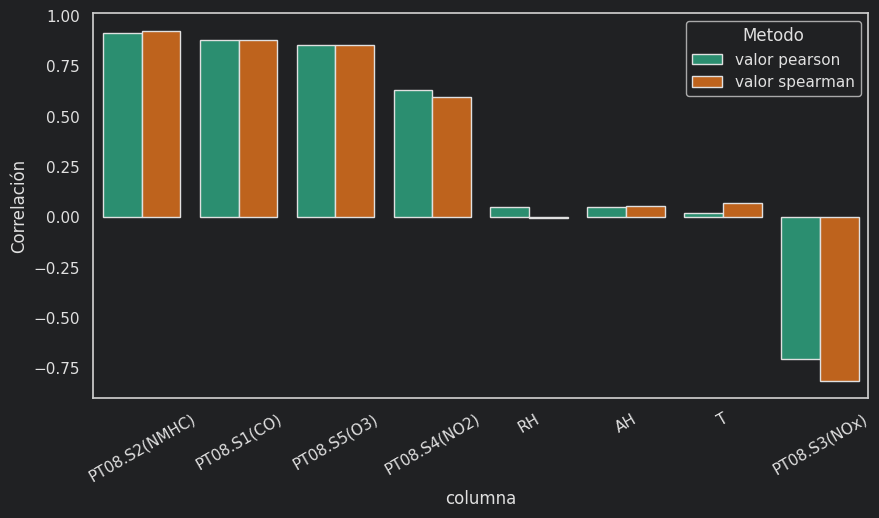

In [ ]:
# voy a entrena el modelo con los datos de los sensores quimicos de bajo costo así que excluyo a los sensores de referencia

X = df.loc[~df['CO(GT)'].isna()]
X = df.drop(['CO(GT)','NMHC(GT)','C6H6(GT)','NOx(GT)','NO2(GT)'], axis=1).copy()
y = df['CO(GT)']

filter_list_pearson_spearman = list_pearson_spearman.loc[list_pearson_spearman['columna'].isin(X.columns)]
filter_list_pearson_spearman = filter_list_pearson_spearman.sort_values(by= ['valor pearson','valor spearman'],ascending=False)

display(filter_list_pearson_spearman)
plt.figure(figsize=(10,5))

df_long = filter_list_pearson_spearman.melt(
    id_vars='columna',
    value_vars=['valor pearson', 'valor spearman'],
    var_name='Metodo',
    value_name='Correlación'
)

sns.barplot(data=df_long,x='columna',y='Correlación',hue='Metodo',order=filter_list_pearson_spearman['columna'].values,palette=sns.color_palette(palette='Dark2'))
plt.xticks(rotation=30)
plt.show()

- Realicé este gráfico para visualizar y ordenar de manera más clara la correlación lineal (Pearson) y la correlación monótona (Spearman) de cada variable con respecto a la variable objetivo, la Concentración Real de Monóxido de Carbono.

- La Lectura del Sensor de Hidrocarburos No Metánicos presenta la mayor correlación con la variable objetivo, siendo predominantemente lineal. Le siguen la Lectura del Sensor de Monóxido de Carbono y la Lectura del Sensor de Ozono, que también muestran correlaciones fuertes tanto lineales como monótonas.
Las variables Humedad Absoluta, Humedad Relativa y Temperatura del Aire presentan correlaciones débiles, tanto lineales como monótonas, por lo que individualmente parecen tener una capacidad explicativa limitada sobre la concentración de monóxido de carbono.
- Una de las variables más influyentes es la Lectura del Sensor de Óxidos de Nitrógeno. Si bien presenta una correlación lineal negativa fuerte, su correlación monótona es aproximadamente un 10% mayor en valor absoluto. Esta diferencia, sumada a la forma observada en el gráfico de dispersión, sugiere la existencia de una relación inversa no lineal entre ambas variables. Visualmente, dicho comportamiento es compatible con una relación logarítmica negativa, donde incrementos iniciales en la lectura del sensor se asocian con disminuciones pronunciadas en la concentración de monóxido de carbono, mientras que para valores más elevados la tasa de disminución se vuelve progresivamente menor.

In [ ]:
display((X.isna().sum()))
display(((X.isna().sum() / X.shape[0]) * 100).round(2))
display(X.loc[X['PT08.S2(NMHC)'].isna()].head(5))

,0
PT08.S1(CO),366
PT08.S2(NMHC),366
PT08.S3(NOx),366
PT08.S4(NO2),366
PT08.S5(O3),366
T,366
RH,366
AH,366


,0
PT08.S1(CO),3.91
PT08.S2(NMHC),3.91
PT08.S3(NOx),3.91
PT08.S4(NO2),3.91
PT08.S5(O3),3.91
T,3.91
RH,3.91
AH,3.91


,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Inicialmente consideré utilizar **KNN Imputer** para imputar los valores faltantes presentes en las variables predictoras. Sin embargo, al analizar la distribución de los datos faltantes observé que estos se encuentran concentrados en los mismos registros para todas las variables de entrada. Este comportamiento me lleva a pensar que el sistema de adquisición o almacenamiento de datos sufrió interrupciones completas durante determinados períodos de tiempo, afectando simultáneamente a todos los sensores. En total, estos registros representan aproximadamente el **3.91% del conjunto de datos**, equivalente a unas **366 horas de medición**.

* Debido a que las observaciones afectadas presentan valores faltantes en todas las variables predictoras, considero que la aplicación de **KNN Imputer** no es la alternativa más adecuada. Aunque el algoritmo podría generar imputaciones utilizando otras observaciones del conjunto de datos, la ausencia total de información en estos registros reduce la confiabilidad de las estimaciones y podría introducir ruido en el modelo.

* Por este motivo, y considerando que el porcentaje de registros afectados es relativamente bajo, decidí eliminar estas observaciones del conjunto de datos. En consecuencia, también eliminaré los valores correspondientes de la variable objetivo (**CO(GT)**), ya que no dispongo de información suficiente en las variables predictoras para estimar de manera fiable dichas observaciones.


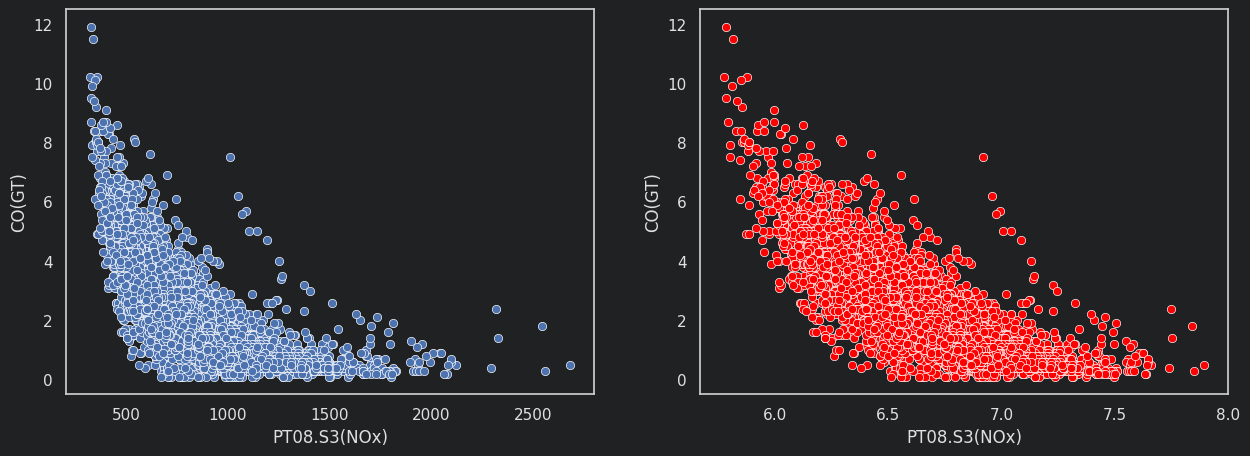

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split



# Filter out rows where 'CO(GT)' or 'PT08.S2(NMHC)' are NaN, and then drop unnecessary columns
X_filtered = df.loc[~(df['PT08.S2(NMHC)'].isna()) & ~(df['CO(GT)'].isna())].copy()
y = X_filtered['CO(GT)']
X = X_filtered.drop(['CO(GT)','NMHC(GT)','C6H6(GT)','NOx(GT)','NO2(GT)'], axis=1)
X_columns = X.columns
# transformo la variable 'PT08.S3(NOx)' a logaritmo natural
figure, axs = plt.subplots(1,2,figsize=(15,5))

copy_PT08 = X['PT08.S3(NOx)'].copy()
sns.scatterplot(x=copy_PT08, y=y,ax=axs[0])

X['PT08.S3(NOx)'] = np.log(X['PT08.S3(NOx)'])

sns.scatterplot(x=X['PT08.S3(NOx)'], y=y,ax=axs[1],color='red')
plt.show()

X_df = pd.DataFrame(X,columns=X_columns)
# luego de limpiar y transformar los datos, procedo a escalar todas las variables a una misma unidad para que los predictores no se vean afectados por las diferentes escalas de las mediciones y se calculen en base a la diferencia entre los datos
standar = StandardScaler()
X = standar.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


- Se suele utilizar el logaritmo natural para transformar variables que presentan relaciones no lineales, ya que esta transformación puede ayudar a linealizar la relación entre las variables y facilitar su modelado mediante técnicas lineales. En particular, cuando una relación presenta una forma compatible con una curva logarítmica, la aplicación del logaritmo natural al predictor puede mejorar la representación de la correlación y aumentar la capacidad explicativa de modelos como la regresión lineal.

- Luego de limpiar y transformar los datos, procedo a escalar todas las variables predictoras a una misma escala. El objetivo de este paso es evitar que las diferencias en las unidades de medida o en los rangos de valores influyan de manera desproporcionada en el entrenamiento del modelo.

- De esta forma, todas las variables contribuyen en condiciones comparables y los algoritmos que se basan en distancias o en la magnitud de los coeficientes pueden evaluar los patrones presentes en los datos sin verse sesgados por la escala original de las mediciones.
- por ultimo separo los conjuntos de entrenamiento y testeo en el que utilizo la distribución 70/30, 70% para entrenar 30% para testear

In [ ]:
display(((X_df.isna().sum() / X_df.shape[0]) * 100).round(2))

,0
PT08.S1(CO),0.0
PT08.S2(NMHC),0.0
PT08.S3(NOx),0.0
PT08.S4(NO2),0.0
PT08.S5(O3),0.0
T,0.0
RH,0.0
AH,0.0


verifico que no tenga nulos

## Resolución:

In [ ]:
LinearRegression = LinearRegression()
modelo = LinearRegression.fit(X_train,y_train)
modelo

LinearRegression()




## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


/tmp/ipykernel_5249/1968187677.py:13: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(data=list_acuracy,x='metrica',y='valor',hue='medición',palette=sns.color_palette(palette='PRGn'))


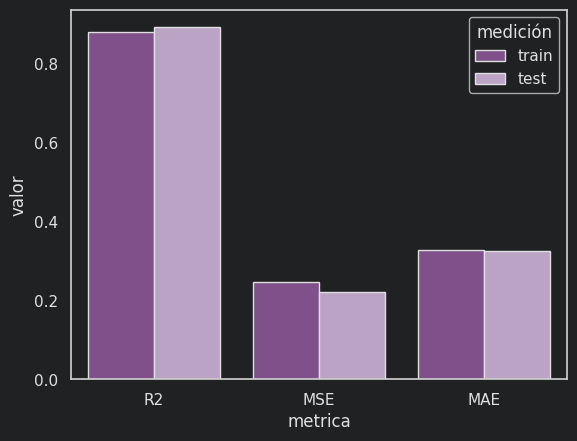

In [ ]:
#r2_score, mean_squared_error, mean_absolute_error
prediccon_train = modelo.predict(X_train)
prediccon_test = modelo.predict(X_test)

list_acuracy = [
    {'medición' : 'train','R2' : r2_score(y_train,prediccon_train),'MSE' : mean_squared_error(y_train,prediccon_train),'MAE' : mean_absolute_error(y_train,prediccon_train)},
    {'medición' : 'test','R2' : r2_score(y_test,prediccon_test),'MSE' : mean_squared_error(y_test,prediccon_test),'MAE' : mean_absolute_error(y_test,prediccon_test)}
]

list_acuracy = pd.DataFrame(list_acuracy)
list_acuracy = list_acuracy.melt(id_vars='medición',var_name='metrica',value_name='valor')

sns.barplot(data=list_acuracy,x='metrica',y='valor',hue='medición',palette=sns.color_palette(palette='PRGn'))
plt.show()

- Si bien cada métrica evalúa el desempeño del modelo desde una perspectiva diferente, el gráfico permite observar que no existe evidencia significativa de sobreajuste (overfitting). Los resultados obtenidos en entrenamiento y prueba son muy similares tanto para R² como para MAE, lo que indica una buena capacidad de generalización del modelo.

- La única diferencia apreciable se observa en la métrica MSE (Error Cuadrático Medio), donde el desempeño en
entrenamiento es ligeramente mejor que en entrenamiento. Esto podría sugerir un leve sobreajuste. Sin embargo, dado que el MSE penaliza más severamente los errores grandes que el MAE, esta diferencia podría estar asociada a la presencia de algunas observaciones con errores elevados en el conjunto de prueba más que a un problema real de generalización del modelo.

In [ ]:
list_acuracy.loc[list_acuracy['medición'] =='test']
list_acuracy.loc[list_acuracy['medición'] =='test']
test_metrica = list_acuracy[list_acuracy['medición'] =='test']
root_metrica = np.sqrt(test_metrica.loc[test_metrica['metrica'] == 'MSE','valor'].values)
display('R2',test_metrica.loc[test_metrica['metrica'] =='R2','valor'].values)
display('SMSE',root_metrica)
display('MSE',test_metrica.loc[test_metrica['metrica'] =='MSE','valor'].values)
display('MAE',test_metrica.loc[test_metrica['metrica'] =='MAE','valor'].values)


'R2'

array([0.89309309])

'SMSE'

array([0.47074258])

'MSE'

array([0.22159858])

'MAE'

array([0.32661223])

Pasando al conjunto de datos limpio:

* El modelo presenta un **R² de 0.8930**, lo que indica que es capaz de explicar aproximadamente el **89.30% de la variabilidad** observada en la concentración real de monóxido de carbono.

* El modelo presenta un **Error Cuadrático Medio (MSE) de 0.22** y una **Raíz del Error Cuadrático Medio (RMSE) de 0.47**. Esto significa que, en promedio, las predicciones del modelo se desvían aproximadamente **0.47 unidades** respecto de los valores reales de la variable objetivo.

* Según la métrica de **Error Absoluto Medio (MAE)**, el modelo se equivoca en promedio **0.32 unidades** respecto del valor real.

* La diferencia entre el **MAE (0.32)** y el **RMSE (0.47)** se debe a que el RMSE penaliza con mayor intensidad los errores grandes o extremos. Por este motivo, cuando existen algunas predicciones con errores elevados, el RMSE tiende a aumentar más que el MAE. En este caso, la diferencia entre ambas métricas sugiere la presencia de algunos errores relativamente grandes, aunque no lo suficientemente importantes como para afectar significativamente el desempeño general del modelo.



## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



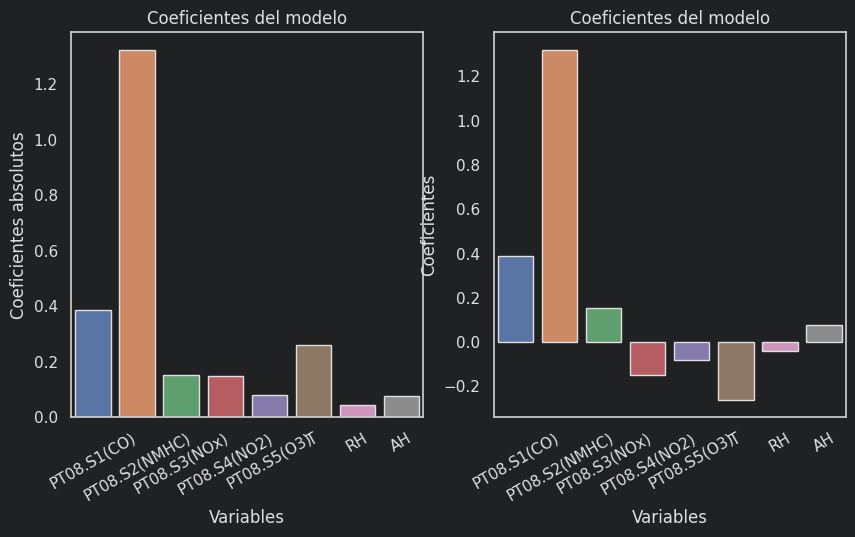

In [ ]:
lista_coeficientes_abs = np.abs(modelo.coef_)
lista_coeficientes = modelo.coef_
fig_coef,ax_coef = plt.subplots(1,2,figsize=(10,5))

sns.barplot(x=X_columns,y=lista_coeficientes_abs,hue=X_columns,ax=ax_coef[0])
ax_coef[0].set_title('Coeficientes del modelo')
ax_coef[0].set_xlabel('Variables')
ax_coef[0].set_ylabel('Coeficientes absolutos')
ax_coef[0].tick_params(axis='x',rotation=30)
ax_coef[1].tick_params(axis='x',rotation=30)

sns.barplot(x=X_columns,y=lista_coeficientes,hue=X_columns,ax=ax_coef[1])
ax_coef[1].set_title('Coeficientes del modelo')
ax_coef[1].set_xlabel('Variables')
ax_coef[1].set_ylabel('Coeficientes')


plt.show()

#df_coeficientes = pd.DataFrame(lista_coeficientes,columns=lista_nombres_coeficientes)


- Observando la magnitud de los coeficientes, puedo notar que el modelo le asigna una importancia mucho mayor a la **Lectura del Sensor de Hidrocarburos No Metánicos** que al propio **Sensor de Monóxido de Carbono** para predecir la concentración real de monóxido de carbono.

- Una posible explicación es que, en las ciudades, una de las principales fuentes de emisión de monóxido de carbono son los vehículos. Estos también emiten hidrocarburos no metánicos, por lo que ambas sustancias suelen aumentar y disminuir al mismo tiempo. Debido a esta relación, la medición de hidrocarburos resulta ser un muy buen indicador de la presencia de monóxido de carbono.

- Esta diferencia puede deberse a que el sensor de hidrocarburos tenga menos ruido o una relación más estable con la concentración real de monóxido de carbono, lo que lleva al modelo a confiar más en esta variable al momento de realizar las predicciones.

- El modelo utiliza el sensor de hidrocarburos como predictor principal y utiliza el resto de predictores como respaldo para mayor precisión.

- Tanto en el analisis previo como en los resultados del modelo se puede verificar que los predictores de humedad y temperaturas no son relevantes para predecir la variable objetivo


###Importancia de las características por permutación

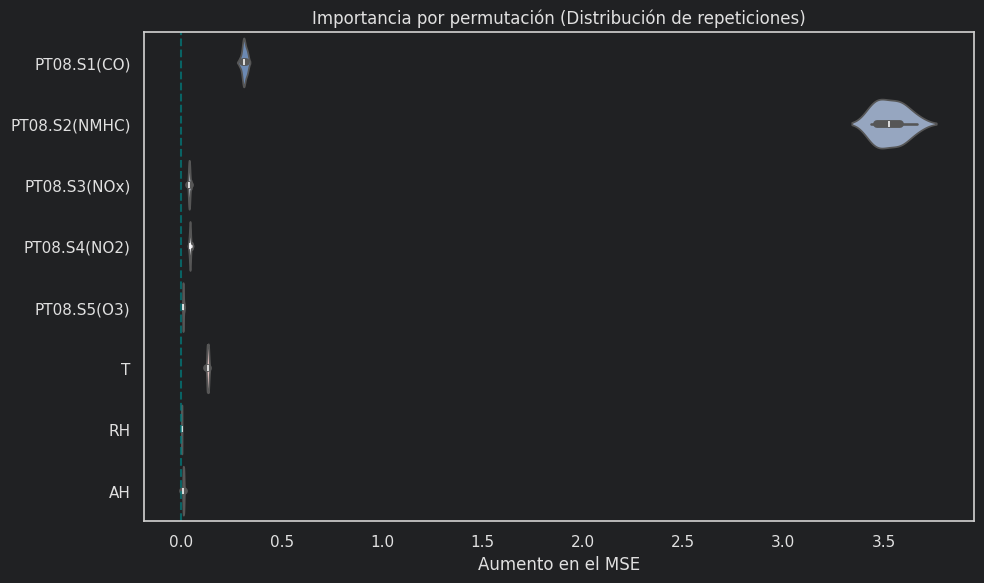

In [ ]:
from sklearn.inspection import permutation_importance
resultado = permutation_importance(modelo, X_test, y_test, scoring='neg_mean_squared_error', n_repeats=10, random_state=42)

# 1. Creamos un DataFrame con las 10 repeticiones por cada columna
df_importancias = pd.DataFrame(resultado.importances.T, columns=X_columns)

# 2. Graficamos usando el DataFrame completo
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_importancias, orient="h", inner="box", palette="vlag")

plt.xlabel("Aumento en el MSE")
plt.title("Importancia por permutación (Distribución de repeticiones)")
plt.axvline(x=0, color="teal", linestyle="--", linewidth=1.5, alpha=0.7)


plt.tight_layout()
plt.show()


- En este gráfico se visualiza cuánto aumenta el error cuadrático medio (MSE) cuando se altera aleatoriamente cada predictor. Cuanto mayor sea el aumento del error, mayor será la dependencia que tiene el modelo de esa variable para realizar sus predicciones.
- Se puede observar que la Lectura del Sensor de Hidrocarburos No Metánicos es la variable más importante para el modelo, ya que al invalidarla se produce el mayor aumento en el error. Muy por detrás aparece la Lectura del Sensor de Monóxido de Carbono, lo que refuerza la idea de que el modelo se apoya principalmente en la información proporcionada por el sensor de hidrocarburos.
- A diferencia del análisis basado en correlaciones y coeficientes, en este caso la Temperatura del Aire muestra una importancia considerable dentro del modelo. Esto puede deberse a que, aunque por sí sola presenta una correlación muy baja con la variable objetivo, aporta información útil cuando se combina con el resto de los predictores. Este comportamiento es habitual en modelos multivariados, donde una variable puede tener poca relación individual con el objetivo pero contribuir a mejorar las predicciones al interactuar con otras variables.


## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:


## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  

Pruevo con quitar las variables correspondientes a la humedad relativa y humedad absoluta

In [ ]:

X_2 = X_df[['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T']]
display(X_2.head())

X_columns2 = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_2, y, test_size=0.3, random_state=42)

modelo2 = LinearRegression()
modelo2 = modelo2.fit(X_train,y_train)

prediccon_train2 = modelo2.predict(X_train)
prediccon_test2 = modelo2.predict(X_test)

,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T
0,1360.0,1046.0,6.962243,1692.0,1268.0,13.6
1,1292.0,955.0,7.068172,1559.0,972.0,13.3
2,1402.0,939.0,7.038784,1555.0,1074.0,11.9
3,1376.0,948.0,6.995766,1584.0,1203.0,11.0
4,1272.0,836.0,7.094235,1490.0,1110.0,11.2


/tmp/ipykernel_5249/3048258180.py:10: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(data=list_acuracy,x='metrica',y='valor',hue='medición',palette=sns.color_palette(palette='PRGn'))


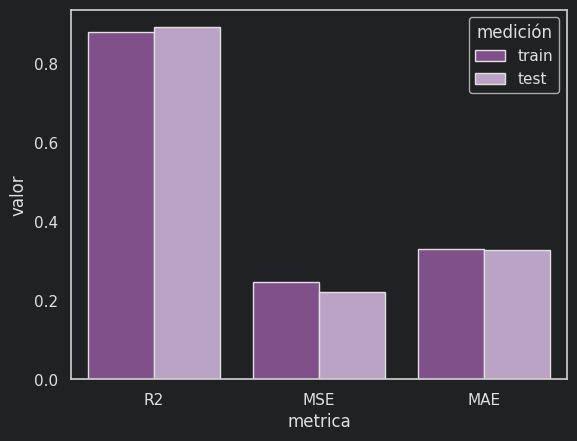

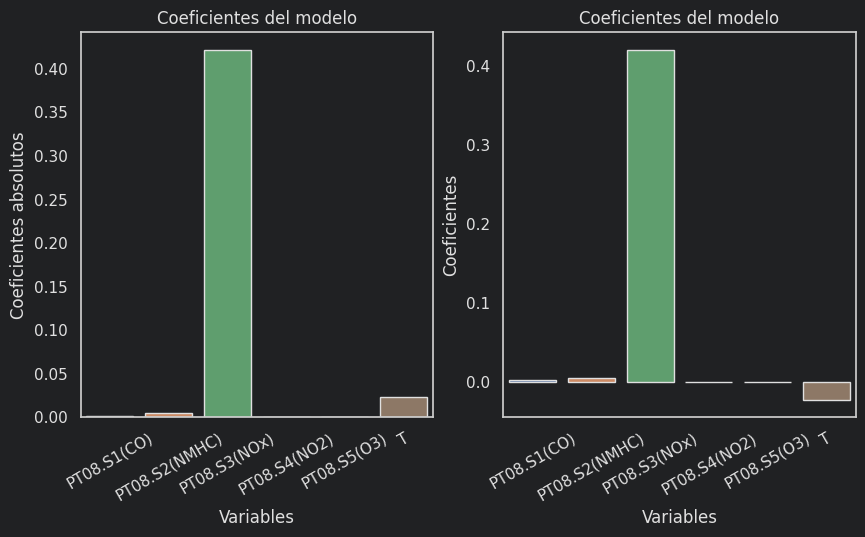

In [ ]:
#r2_score, mean_squared_error, mean_absolute_error
list_acuracy = [
    {'medición' : 'train','R2' : r2_score(y_train2,prediccon_train2),'MSE' : mean_squared_error(y_train,prediccon_train),'MAE' : mean_absolute_error(y_train2,prediccon_train2)},
    {'medición' : 'test','R2' : r2_score(y_test2,prediccon_test2),'MSE' : mean_squared_error(y_test2,prediccon_test2),'MAE' : mean_absolute_error(y_test2,prediccon_test2)}
]

list_acuracy = pd.DataFrame(list_acuracy)
list_acuracy = list_acuracy.melt(id_vars='medición',var_name='metrica',value_name='valor')

sns.barplot(data=list_acuracy,x='metrica',y='valor',hue='medición',palette=sns.color_palette(palette='PRGn'))


lista_coeficientes_abs2 = np.abs(modelo2.coef_)
lista_coeficientes2 = modelo2.coef_
fig_coef2,ax_coef2 = plt.subplots(1,2,figsize=(10,5))

sns.barplot(x=X_columns2,y=lista_coeficientes_abs2,hue=X_columns2,ax=ax_coef2[0])
ax_coef2[0].set_title('Coeficientes del modelo')
ax_coef2[0].set_xlabel('Variables')
ax_coef2[0].set_ylabel('Coeficientes absolutos')
ax_coef2[0].tick_params(axis='x',rotation=30)
ax_coef2[1].tick_params(axis='x',rotation=30)

sns.barplot(x=X_columns2,y=lista_coeficientes2,hue=X_columns2,ax=ax_coef2[1])
ax_coef2[1].set_title('Coeficientes del modelo')
ax_coef2[1].set_xlabel('Variables')
ax_coef2[1].set_ylabel('Coeficientes')




plt.show()


---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  
- Al final de su trabajo debe crear un apartado de REFERENCIAS para citar todo recurso utilizado. Si usó IA, debe


- https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html
- https://archive.ics.uci.edu/dataset/387/air+quality?utm_source=chatgpt.com
- https://cienciadedatos.net/documentos/py10b-regresion-lineal-multiple-python (este vlog me ayudo a entender en que consiste la transformación logarítmica.)
